# MODEL BUILDING

## 1.Checking Requirements 

### 1.1 Import Required Libraries 

In [1]:
!pip install hmmlearn

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from hmmlearn import hmm

from sklearn.preprocessing import KBinsDiscretizer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve 




### 1.2 Uploading Dataset

In [3]:
model_results = []
df = pd.read_csv('clean_dataset.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])


### Selecting features

In [4]:
selected_features = ['Amount', 'trans_hour', 'FailedAttempts', 'Amount_to_Avg_Ratio', 'AvgTransactionAmount']
X = df[selected_features]
y = df['FraudFlag']

### 1.3 Injecting Realistic Noise

In [5]:
np.random.seed(42)
train_fraud_idx = y[y == 1].index

noise_idx = np.random.choice(train_fraud_idx, size=int(len(train_fraud_idx) * 0.7), replace=False)

X.loc[noise_idx, 'FailedAttempts'] = np.random.randint(5, 10, size=len(noise_idx))
X.loc[noise_idx, 'trans_hour'] = np.random.randint(0, 5, size=len(noise_idx))
X.loc[noise_idx, 'Amount_to_Avg_Ratio'] = np.random.uniform(5, 15, size=len(noise_idx))

### 1.4 Train -Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### 1.5 Data Balancing SMOTE

In [7]:
sm = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# MODEL TRAINING USING ALGORITHMS

## 1. RANDOM FOREST

In [8]:
# TRAIN RANDOM FOREST 

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_res, y_train_res)
y_pred = rf_model.predict(X_test)


In [9]:
# PROBABILITY PREDICTION

y_prob = rf_model.predict_proba(X_test)[:,1]
# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_prob)

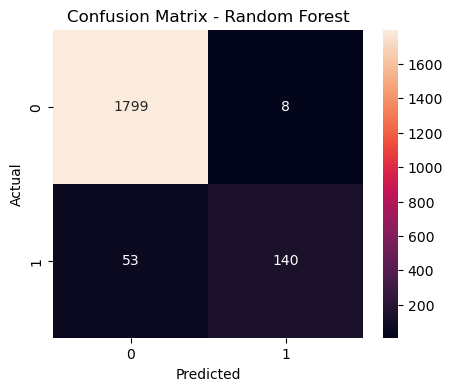

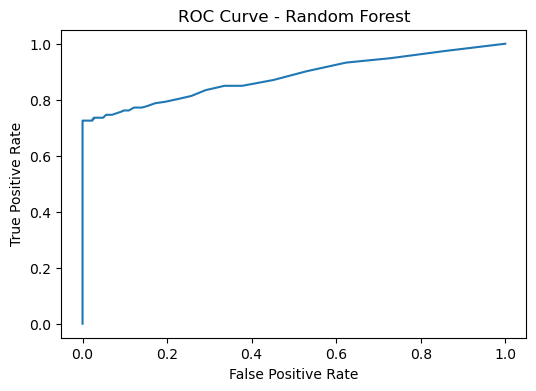

In [10]:
## CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## ROC CURVE

fpr, tpr, threshold = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [11]:
# CALCULATING PROBABILITIES

probs = rf_model.predict_proba(X_test)[:, 1]
results = X_test.copy()
results['Actual_Fraud'] = y_test
results['Fraud_Probability'] = probs


top_suspects = results.sort_values(by='Fraud_Probability', ascending=False).head(10)

print("--- Top 10 Transactions Flagged for Manual Review ---")
print(top_suspects[['FailedAttempts', 'Fraud_Probability','trans_hour', 'Actual_Fraud']])

# FINAL EVALUATION

print("---------- Model Performance ----------")
print(classification_report(y_test, rf_model.predict(X_test)))
print("ROC AUC Score:", roc_auc)


--- Top 10 Transactions Flagged for Manual Review ---
      FailedAttempts  Fraud_Probability  trans_hour  Actual_Fraud
7952               8                1.0           1             1
3108               7                1.0           2             1
9009               5                1.0           0             1
9736               5                1.0           0             1
1278               7                1.0           2             1
7052               5                1.0           3             1
86                 8                1.0           4             1
5281               9                1.0           0             1
1729               6                1.0           4             1
5127               6                1.0           0             1
---------- Model Performance ----------
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1807
           1       0.95      0.73      0.82       193

    accuracy    

## 2. LOGISTIC REGRESSION

In [12]:
# TRAIN LOGISTIC REGRESSION

lr_model = LogisticRegression(class_weight='balanced', max_iter=6000)
lr_model.fit(X_train_res, y_train_res)
y_pred_lr = lr_model.predict(X_test)


In [13]:
# Probability prediction
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

# ROC AUC Score
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)


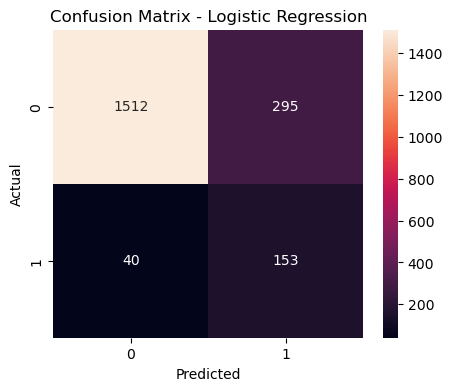

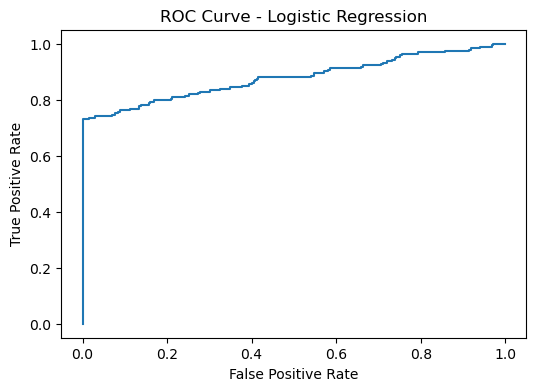

In [14]:
# CONFUSION MATRIX

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC CURVE 

fpr_lr, tpr_lr, threshold = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6,4))
plt.plot(fpr_lr, tpr_lr)
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


In [15]:
# PREDICT AND EVALUATE 

y_pred = lr_model.predict(X_test)
print("--- Logistic Regression Results ---")
print(classification_report(y_test, y_pred))
print("Logistic Regression ROC AUC:", roc_auc_lr)

--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      1807
           1       0.34      0.79      0.48       193

    accuracy                           0.83      2000
   macro avg       0.66      0.81      0.69      2000
weighted avg       0.91      0.83      0.86      2000

Logistic Regression ROC AUC: 0.8776146878431891


## 3. DECISION TREE

In [16]:
# TRAIN DECISION TREE 

from sklearn.tree import DecisionTreeClassifier
# selected_features = ['Amount', 'trans_hour', 'FailedAttempts', 'Amount_to_Avg_Ratio','AvgTransactionAmount']
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train_res, y_train_res)
y_pred_dt = dt_model.predict(X_test)

In [17]:
# Probability prediction
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

# ROC AUC Score
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
print("Decision Tree ROC AUC:", roc_auc_dt)

Decision Tree ROC AUC: 0.8464936301257918


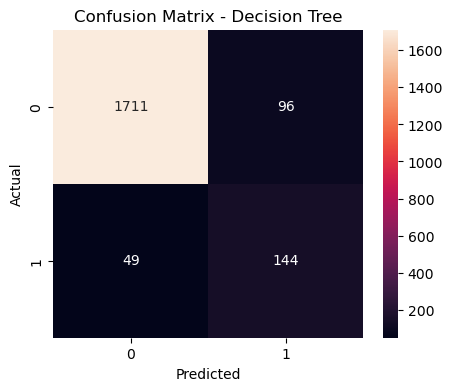

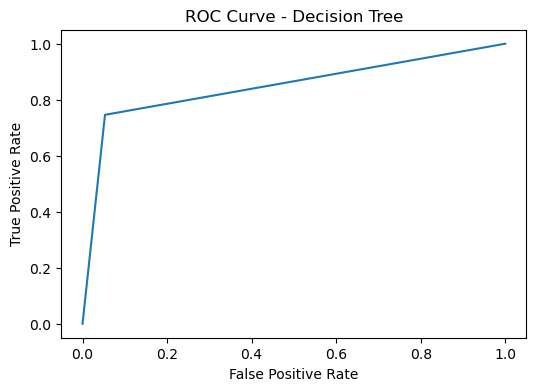

In [18]:
# CONFUSION MATRIX 

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d')

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC CURVE 

fpr_dt, tpr_dt, threshold = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(6,4))
plt.plot(fpr_dt, tpr_dt)
plt.title("ROC Curve - Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

In [19]:
# PREDICT AND EVALUATE 

y_pred_dt = dt_model.predict(X_test[selected_features])
print("--- Decision Tree Results ---")
print(classification_report(y_test, y_pred_dt))
print("Decision Tree ROC AUC:", roc_auc_dt)

--- Decision Tree Results ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1807
           1       0.60      0.75      0.67       193

    accuracy                           0.93      2000
   macro avg       0.79      0.85      0.81      2000
weighted avg       0.94      0.93      0.93      2000

Decision Tree ROC AUC: 0.8464936301257918


## 4. AUTOENCODER

In [20]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [21]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import numpy as np
import random


In [22]:
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [23]:
# 1. Define Selected Features

selected_features = ['Amount', 'trans_hour', 'FailedAttempts', 'Amount_to_Avg_Ratio']


In [24]:
# 2. Scaling  for the selected features

ae_scaler = MinMaxScaler()
X_train_ae = ae_scaler.fit_transform(X_train_res[selected_features])
X_test_ae = ae_scaler.transform(X_test[selected_features])

In [25]:
# 3. Filter for Normal transactions 

X_train_normal = X_train_ae[y_train_res == 0]
input_dim = X_train_normal.shape[1] 


In [26]:
# 4. Build Architecture
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(8, activation='relu')(input_layer)
encoded = Dense(2, activation='relu')(encoded) # Tight bottleneck for 4 features

# Decoder
decoded = Dense(8, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

In [27]:
# 5. Train

print("Training Autoencoder on selected features...")
autoencoder.fit(X_train_normal, X_train_normal, epochs=50, batch_size=32, verbose=0)

Training Autoencoder on selected features...


In [28]:
# 6. Detect Anomalies

predictions = autoencoder.predict(X_test_ae)
mse = np.mean(np.power(X_test_ae - predictions, 2), axis=1)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [29]:
# 7. Thresholding (Top 10% error = Fraud)

threshold = np.percentile(mse, 90) 
y_pred_ae = (mse > threshold).astype(int)

In [30]:
# 8. Evaluate

print("\n--- Autoencoder with Feature Selection Results ---")
print(classification_report(y_test, y_pred_ae))


--- Autoencoder with Feature Selection Results ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1807
           1       0.71      0.74      0.73       193

    accuracy                           0.95      2000
   macro avg       0.84      0.85      0.85      2000
weighted avg       0.95      0.95      0.95      2000



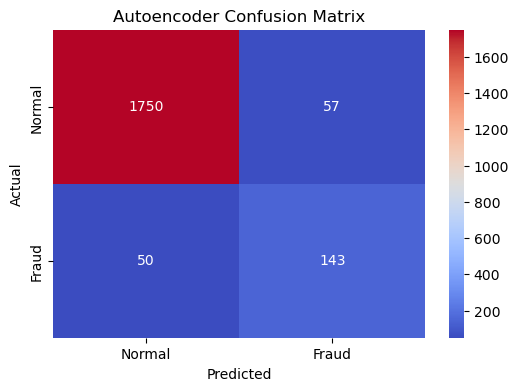

Autoencoder ROC AUC Score: 0.8650842578229166


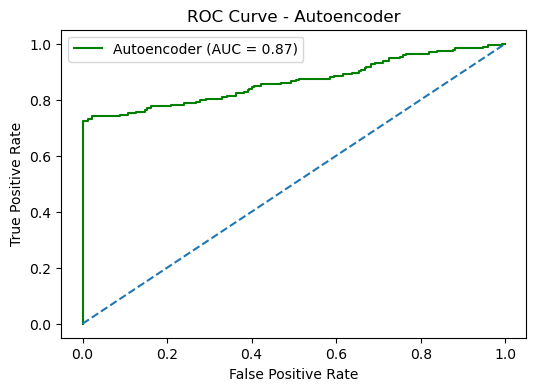

In [31]:
# Confusion Matrix 

cm_ae = confusion_matrix(y_test, y_pred_ae)

plt.figure(figsize=(6,4))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])

plt.title('Autoencoder Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


# ROC Curve 

roc_auc_ae = roc_auc_score(y_test, mse)

print("Autoencoder ROC AUC Score:", roc_auc_ae)
fpr_ae, tpr_ae, thresholds = roc_curve(y_test, mse)
plt.figure(figsize=(6,4))

plt.plot(fpr_ae,
         tpr_ae,
         color='green',
         label=f'Autoencoder (AUC = {roc_auc_ae:.2f})')

plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve - Autoencoder')

plt.legend()

plt.show()

In [32]:
# from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# print("Hybrid Model Results\n")

# print(classification_report(y_test, y_pred_hybrid))

# print("Accuracy:", accuracy_score(y_test, y_pred_hybrid))

# print("ROC-AUC:", roc_auc_score(y_test, hybrid_score))

## 5. ISOLATION FOREST

In [33]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
import numpy as np

In [34]:
# 1. Select the High-Impact Features

selected_features = ['Amount', 'trans_hour', 'FailedAttempts', 'Amount_to_Avg_Ratio','AvgTransactionAmount']

In [35]:
# 2. Initialize Isolation Forest

iso_forest = IsolationForest(
    n_estimators=100, 
    contamination=0.1, 
    max_features=1.0, 
    random_state=42
)

In [36]:
# 3. Fit and Predict using ONLY the selected features

iso_forest.fit(X_train[selected_features])

IsolationForest(contamination=0.1, random_state=42)

In [37]:
# 4. Generate Predictions

raw_preds = iso_forest.predict(X_test[selected_features])

In [38]:
# 5. Map results to match your labels (0 = Normal, 1 = Fraud)
y_pred_iso = [1 if x == -1 else 0 for x in raw_preds]

In [39]:
# 6. Evaluation

print("--- Isolation Forest with Feature Selection ---")
print(classification_report(y_test, y_pred_iso, labels=[0, 1]))

--- Isolation Forest with Feature Selection ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1807
           1       0.56      0.58      0.57       193

    accuracy                           0.92      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.92      0.92      0.92      2000



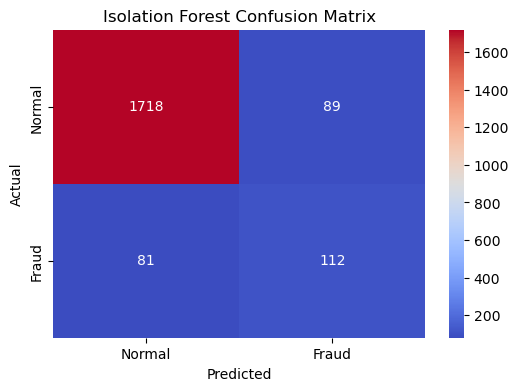

In [40]:
# Confusion Matrix 

cm_iso = confusion_matrix(y_test, y_pred_iso)

plt.figure(figsize=(6,4))
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])

plt.title('Isolation Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

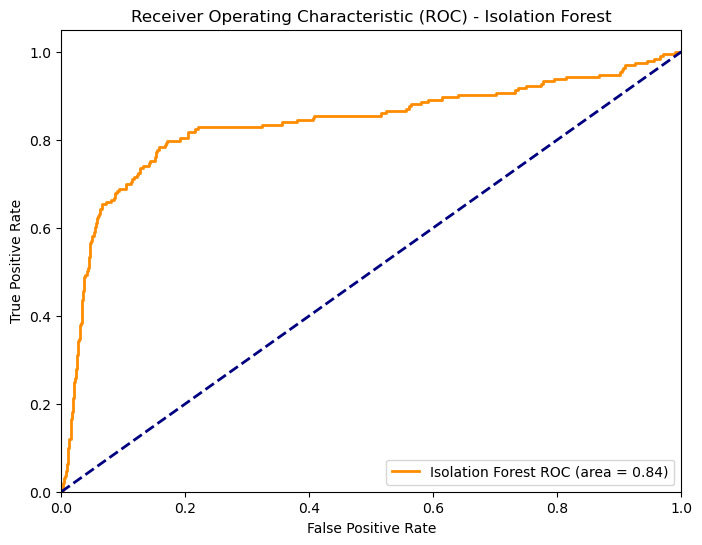

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Get anomaly scores from the Isolation Forest model
# Note: decision_function returns negative values for outliers; 
# we invert it so higher scores represent higher fraud probability.
if_scores = -iso_forest.decision_function(X_test)

# 2. Calculate ROC curve and AUC score
fpr_if, tpr_if, thresholds_if = roc_curve(y_test, if_scores)
roc_auc_if = roc_auc_score(y_test, if_scores)

# 3. Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_if, tpr_if, color='darkorange', lw=2, label=f'Isolation Forest ROC (area = {roc_auc_if:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Isolation Forest')
plt.legend(loc="lower right")
plt.show()

## 6. HYBRID MODEL (Autoencoder and RandomForest)

In [42]:
# Random Forest Probabilities

rf_prob = rf_model.predict_proba(X_test[selected_features])[:,1]

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

ae_score = scaler.fit_transform(mse.reshape(-1,1)).flatten()

# Hybrid Score

hybrid_rf_ae_score = 0.6 * rf_prob + 0.4 * ae_score

threshold = 0.4

y_pred_rf_ae = (hybrid_rf_ae_score > threshold).astype(int)

from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

print("Hybrid Random Forest + Autoencoder")

print(classification_report(y_test, y_pred_rf_ae))

print("Accuracy:", accuracy_score(y_test, y_pred_rf_ae))

print("ROC-AUC:", roc_auc_score(y_test, hybrid_rf_ae_score))

Hybrid Random Forest + Autoencoder
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1807
           1       0.97      0.73      0.83       193

    accuracy                           0.97      2000
   macro avg       0.97      0.86      0.91      2000
weighted avg       0.97      0.97      0.97      2000

Accuracy: 0.9715
ROC-AUC: 0.8811903048306672


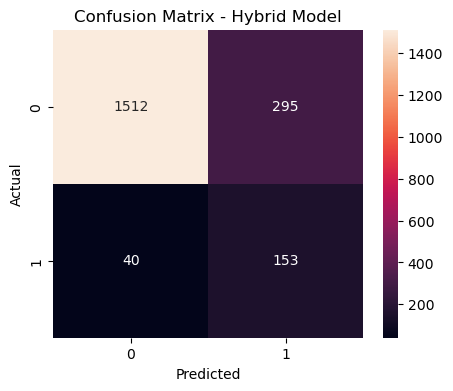

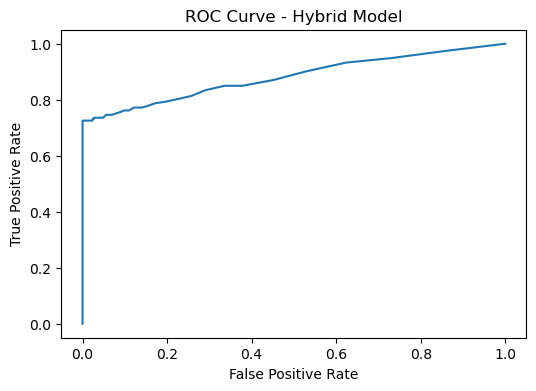

In [43]:
cm_hybrid = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_hybrid, annot=True, fmt='d')

plt.title("Confusion Matrix - Hybrid Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()



# ROC CURVE 

fpr_hybrid, tpr_hybrid, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr_hybrid, tpr_hybrid)

plt.title("ROC Curve - Hybrid Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()


## COMPARISION OF ALL THE MODELS USED 

In [44]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import pandas as pd

# List of models and their names to compare
trained_models = {
    "Random Forest": rf_model,
    "Logistic Regression": lr_model,
    "Decision tree": dt_model,
    # "Gradient Boost": gb_model
}

comparison_data = []

for name, model in trained_models.items():
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Store metrics for both classes
    for label in ['0', '1']:
        comparison_data.append({
            "Algorithm": name,
            "Class": "Normal (0)" if label == '0' else "Fraud (1)",
            "Precision": report[label]['precision'],
            "Recall": report[label]['recall'],
            "F1-Score": report[label]['f1-score'],
            "Accuracy": accuracy_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })




# Adding Isolation Forest

report_iso = classification_report(y_test, y_pred_iso, output_dict=True)

for label in ['0', '1']:
    comparison_data.append({
        "Algorithm": "Isolation Forest",
        "Class": "Normal (0)" if label == '0' else "Fraud (1)",
        "Precision": report_iso[label]['precision'],
        "Recall": report_iso[label]['recall'],
        "F1-Score": report_iso[label]['f1-score'],
        "Accuracy": accuracy_score(y_test, y_pred_iso),
        "ROC-AUC": roc_auc_score(y_test, if_scores)
    })


# Adding Autoencoder

report_ae = classification_report(y_test, y_pred_ae, output_dict=True)

for label in ['0', '1']:
    comparison_data.append({
        "Algorithm": "Autoencoder",
        "Class": "Normal (0)" if label == '0' else "Fraud (1)",
        "Precision": report_ae[label]['precision'],
        "Recall": report_ae[label]['recall'],
        "F1-Score": report_ae[label]['f1-score'],
        "Accuracy": accuracy_score(y_test, y_pred_ae),
        "ROC-AUC": roc_auc_score(y_test, mse)
    })


report_hybrid = classification_report(y_test, y_pred_rf_ae, output_dict=True)

for label in ['0', '1']:
    comparison_data.append({
        "Algorithm": "Hybrid (RF + Autoencoder)",
        "Class": "Normal (0)" if label == '0' else "Fraud (1)",
        "Precision": report_hybrid[label]['precision'],
        "Recall": report_hybrid[label]['recall'],
        "F1-Score": report_hybrid[label]['f1-score'],
        "Accuracy": accuracy_score(y_test, y_pred_rf_ae),
        "ROC-AUC": roc_auc_score(y_test, hybrid_rf_ae_score)
    })





# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Keep only Fraud class
comparison_df = comparison_df[comparison_df["Class"] == "Fraud (1)"]

# Pivot Table
final_table = comparison_df.pivot(index="Algorithm", columns="Class")

#Display Table 
display(
    final_table.style
    .set_properties(**{
        'text-align': 'center',
        'padding': '8px'
    })
    .set_table_styles([
        {'selector': 'th', 
         'props': [('padding', '10px'),
                   ('text-align', 'center')]},
        {'selector': 'td', 
         'props': [('padding', '10px')]}
    ])
)

,Precision,Recall,F1-Score,Accuracy,ROC-AUC
Class,Fraud (1),Fraud (1),Fraud (1),Fraud (1),Fraud (1)
Algorithm,,,,,
Autoencoder,0.715000,0.740933,0.727735,0.946500,0.865084
Decision tree,0.600000,0.746114,0.665127,0.927500,0.846494
Hybrid (RF + Autoencoder),0.972222,0.725389,0.830861,0.971500,0.881190
Isolation Forest,0.557214,0.580311,0.568528,0.915000,0.835734
Logistic Regression,0.341518,0.792746,0.477379,0.832500,0.877615
Random Forest,0.945946,0.725389,0.821114,0.969500,0.881149


## Adding graph and visuals

In [45]:
# Create Final Table
comparison_df = pd.DataFrame(comparison_data)

comparison_df = comparison_df[comparison_df["Class"] == "Fraud (1)"]


# ==============================
# GRAPHS START FROM HERE
# ==============================

sns.set_style("whitegrid")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12



## Acurracy

C:\Users\bhard\AppData\Local\Temp\ipykernel_8592\2463860692.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


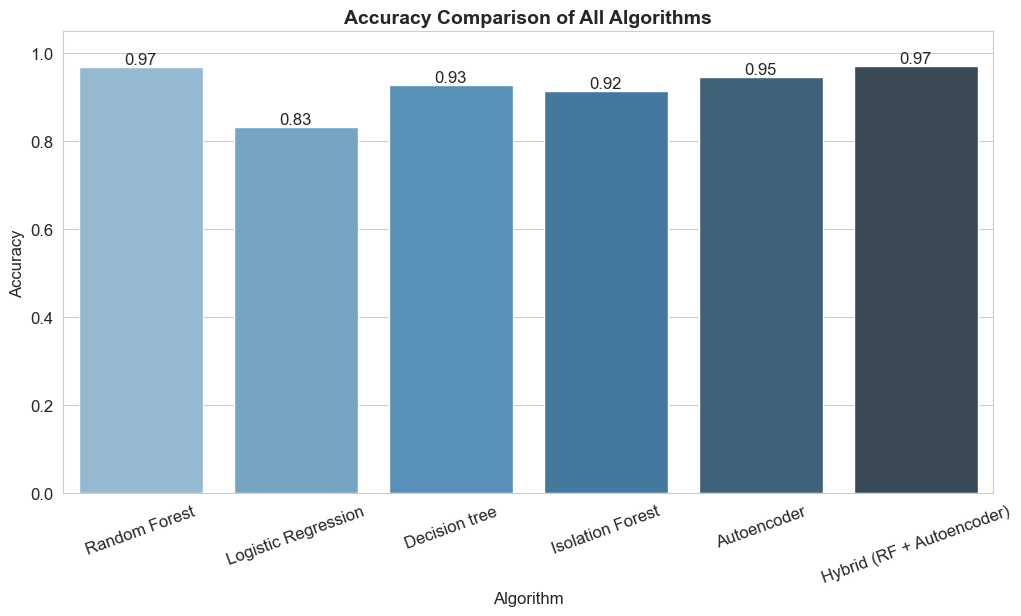

In [46]:
plt.figure()

ax = sns.barplot(
    data=comparison_df,
    x="Algorithm",
    y="Accuracy",
    palette="Blues_d",
    errorbar=None 
)

plt.title("Accuracy Comparison of All Algorithms", fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.ylim(0,1.05)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

## Precision

C:\Users\bhard\AppData\Local\Temp\ipykernel_8592\588053499.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


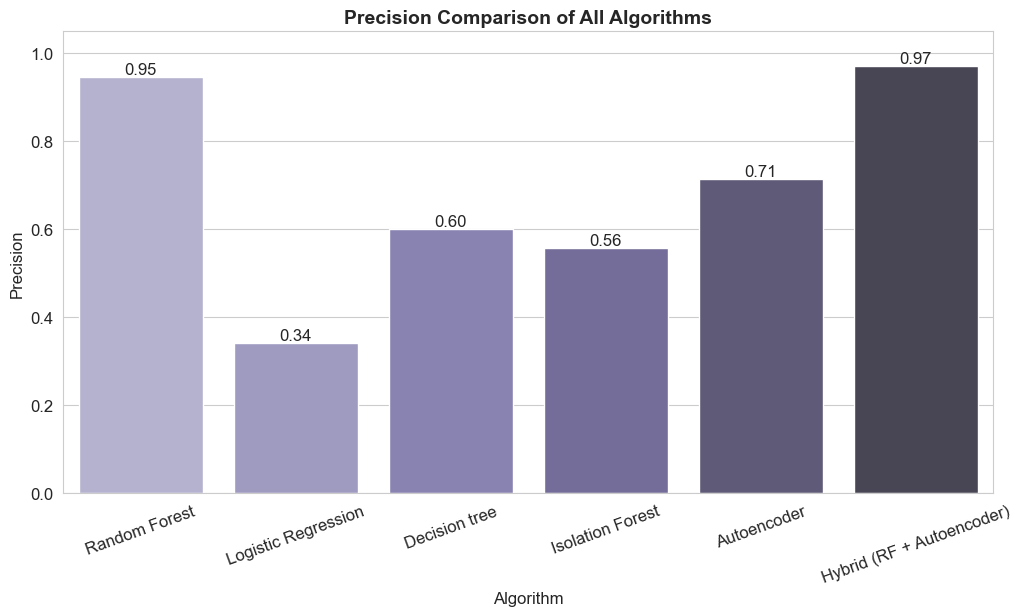

In [47]:
plt.figure()

ax = sns.barplot(
    data=comparison_df,
    x="Algorithm",
    y="Precision",
    palette="Purples_d",
    errorbar=None 
)

plt.title("Precision Comparison of All Algorithms", fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.ylim(0,1.05)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

## Recall

C:\Users\bhard\AppData\Local\Temp\ipykernel_8592\4200668855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


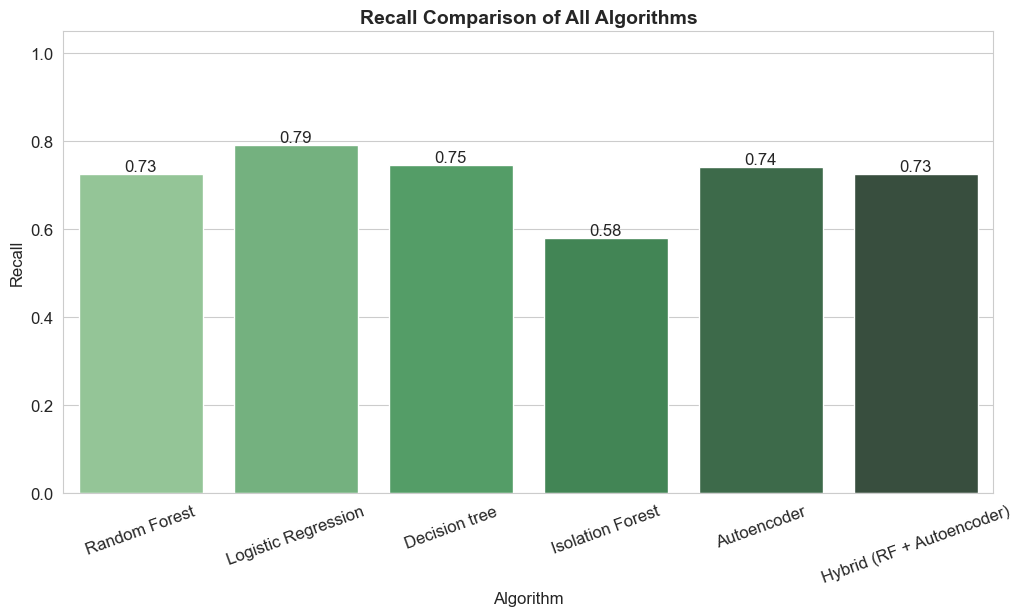

In [48]:
plt.figure()

ax = sns.barplot(
    data=comparison_df,
    x="Algorithm",
    y="Recall",
    palette="Greens_d",
    errorbar=None 
)

plt.title("Recall Comparison of All Algorithms", fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.ylim(0,1.05)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

## F1 Score

C:\Users\bhard\AppData\Local\Temp\ipykernel_8592\633310802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


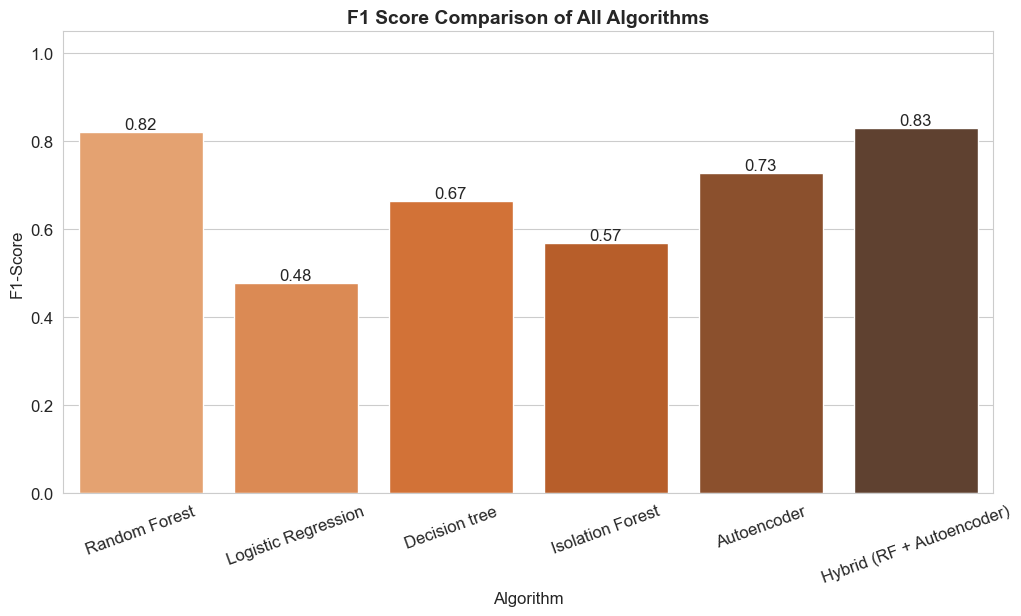

In [49]:
plt.figure()

ax = sns.barplot(
    data=comparison_df,
    x="Algorithm",
    y="F1-Score",
    palette="Oranges_d",
    errorbar=None 
)

plt.title("F1 Score Comparison of All Algorithms", fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.ylim(0,1.05)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

## ROC AUC

C:\Users\bhard\AppData\Local\Temp\ipykernel_8592\3455987283.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


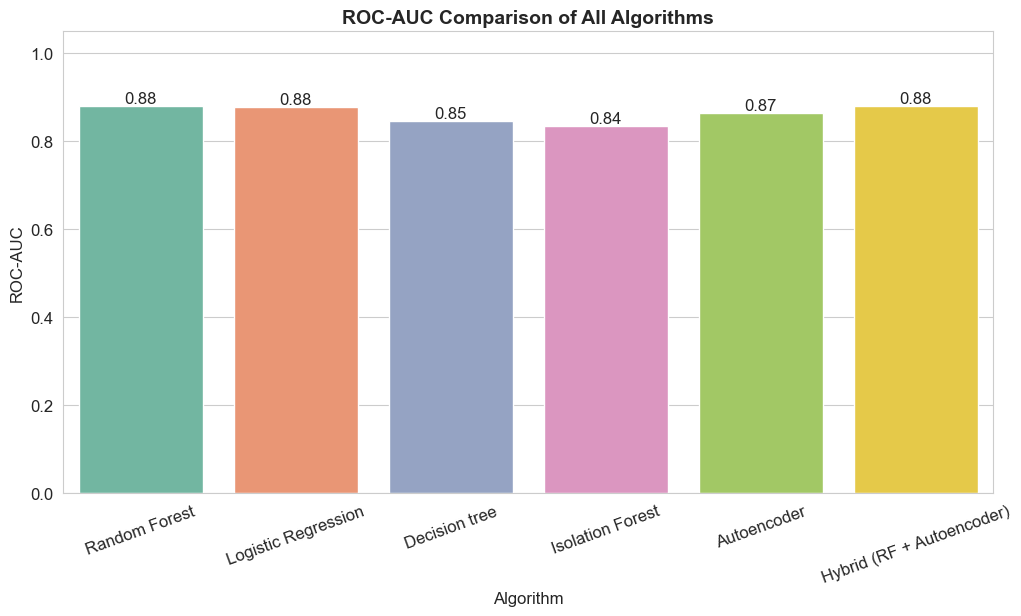

In [50]:
plt.figure()

ax = sns.barplot(
    data=comparison_df,
    x="Algorithm",
    y="ROC-AUC",
    palette="Set2"
)

plt.title("ROC-AUC Comparison of All Algorithms", fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.ylim(0,1.05)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

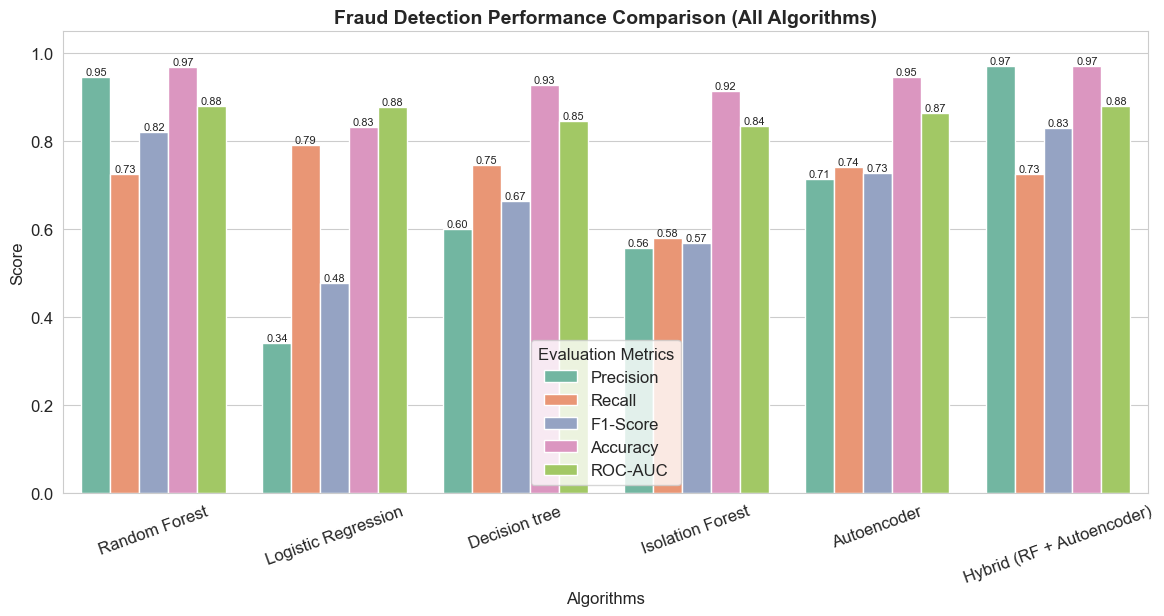

In [51]:
fraud_df = comparison_df[comparison_df["Class"] == "Fraud (1)"]
fraud_melted = fraud_df.melt(
    id_vars="Algorithm",
    value_vars=["Precision", "Recall", "F1-Score", "Accuracy", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)
plt.figure(figsize=(14,6))

ax = sns.barplot(
    data=fraud_melted,
    x="Algorithm",
    y="Score",
    hue="Metric",
    palette="Set2",
    errorbar=None
)

plt.title("Fraud Detection Performance Comparison (All Algorithms)", 
          fontsize=14, weight='bold')

plt.ylabel("Score")
plt.xlabel("Algorithms")

plt.ylim(0,1.05)
plt.xticks(rotation=20)

plt.legend(title="Evaluation Metrics")

# Add values on bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom',
                    fontsize=8)

plt.show()


In [52]:
import joblib
import os

# Create folder relative to notebook
save_dir = r"../final model"
os.makedirs(save_dir, exist_ok=True)

# Save Random Forest Model
model_path = os.path.join(save_dir, "upi_fraud_model.pkl")
joblib.dump(rf_model, model_path)
print(f"Model saved at: {model_path}")

# Save Scaler
try:
    scaler_path = os.path.join(save_dir, "scaler.pkl")
    joblib.dump(scaler, scaler_path)
    print(f"Scaler saved at: {scaler_path}")
except NameError:
    print("No scaler found to save.")


Model saved at: ../final model\upi_fraud_model.pkl
Scaler saved at: ../final model\scaler.pkl
